# Cost Approximation Training

Train `CostApproximation` from the saved tensor map dataset. The loaders below use index batches with `batch_size=None`, so each batch is one direct tensor slice instead of many row fetches followed by collation.


In [ ]:
import sys, platform, multiprocessing, os, random
from pathlib import Path

import numpy as np


import torch as t
from torch.utils.data import DataLoader, random_split, ConcatDataset

REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "apps" / "search_agent").is_dir())
APPS_ROOT = REPO_ROOT / "apps"
if str(APPS_ROOT) not in sys.path:
    sys.path.insert(0, str(APPS_ROOT))

from search_agent.search.deep_learn.cost_apprx import MapCostDataset
from search_agent.search.deep_learn.cost_model import CostApproximation, CostApproximationEval, CostApproximationLoss
from search_agent.search.deep_learn.dataset import make_index_batch_sampler


In [2]:
USE_MULTIPROCESSING = False

if platform.system() in ["Darwin", "Linux"] and USE_MULTIPROCESSING:
    multiprocessing.set_start_method("fork", force=True)

MP_CONTEXT = multiprocessing.get_start_method() if USE_MULTIPROCESSING else None
NUM_WORKERS = 4 if USE_MULTIPROCESSING else 0
USE_PERSISTENT_WORKERS = False

DEVICE = t.device("cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu")
CUDA = DEVICE.type == "cuda"
PIN_MEMORY = CUDA
NON_BLOCKING = PIN_MEMORY

print(f"Using device={DEVICE}")
print(f"Using multiprocessing context={MP_CONTEXT}, workers={NUM_WORKERS}")


def set_seed(seed):
    """Seed Python, NumPy, and PyTorch for reproducible notebook runs."""
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    os.environ["PYTHONHASHSEED"] = str(seed)

    t.manual_seed(seed)
    t.cuda.manual_seed(seed)
    t.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    t.backends.cudnn.deterministic = True
    t.backends.cudnn.benchmark = False
    t.use_deterministic_algorithms(True)


MASTER_SEED = 42
set_seed(MASTER_SEED)
G = t.Generator().manual_seed(MASTER_SEED)


def worker_init_fn(worker_id):
    """Seed each DataLoader worker from the notebook seed."""
    worker_seed = MASTER_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    t.manual_seed(worker_seed)


DATALOADER_WORKER_INIT_FN = worker_init_fn if NUM_WORKERS else None
DATALOADER_PERSISTENT_WORKERS = USE_PERSISTENT_WORKERS if NUM_WORKERS else False
DATALOADER_MP_CONTEXT = MP_CONTEXT if NUM_WORKERS else None


Using device=cpu
Using multiprocessing context=None, workers=0


In [3]:
set_seed(MASTER_SEED)
G.manual_seed(MASTER_SEED)

dataset_paths = (APPS_ROOT / f"search_agent/search/deep_learn/data/cost_approx_random_sampling_dataset_{i + 1}.pt" for i in range(2))
dataset = ConcatDataset((MapCostDataset.load(path) for path in dataset_paths))


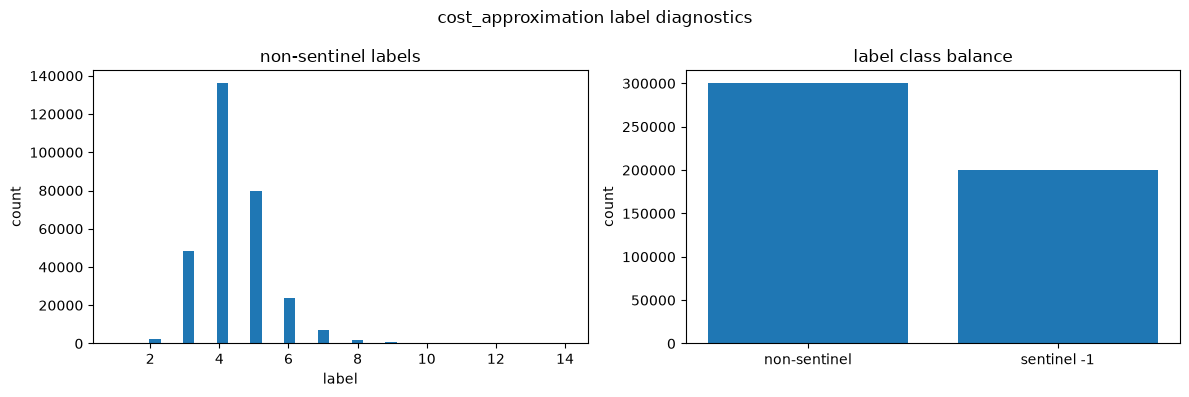

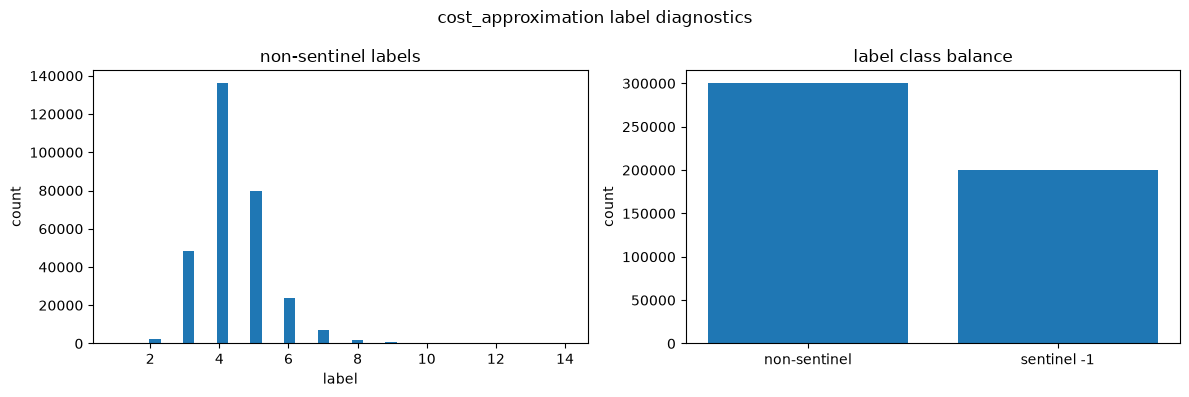

In [5]:
set_seed(MASTER_SEED)
G.manual_seed(MASTER_SEED)

dataset.datasets[1].plot_label_distribution()

In [10]:
set_seed(MASTER_SEED)
G.manual_seed(MASTER_SEED)

length = len(dataset)
print(f"Dataset loaded from  with {length} examples.")

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [0.8, 0.1, 0.1],
    generator=G,
)

batch_size = 512
train_batch_sampler = make_index_batch_sampler(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=G,
)
val_batch_sampler = make_index_batch_sampler(val_dataset, batch_size=batch_size, shuffle=False)
test_batch_sampler = make_index_batch_sampler(test_dataset, batch_size=batch_size, shuffle=False)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=DATALOADER_WORKER_INIT_FN,
    persistent_workers=DATALOADER_PERSISTENT_WORKERS,
    multiprocessing_context=DATALOADER_MP_CONTEXT,
)
val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=DATALOADER_WORKER_INIT_FN,
    persistent_workers=DATALOADER_PERSISTENT_WORKERS,
    multiprocessing_context=DATALOADER_MP_CONTEXT,
)
test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=DATALOADER_WORKER_INIT_FN,
    persistent_workers=DATALOADER_PERSISTENT_WORKERS,
    multiprocessing_context=DATALOADER_MP_CONTEXT,
)


Dataset loaded from  with 1000000 examples.


In [11]:
set_seed(MASTER_SEED)
G.manual_seed(MASTER_SEED)

model = CostApproximation(
    loss_fn=CostApproximationLoss(reachability_weight=0.5),
    eval_fn=CostApproximationEval(),
).to(DEVICE)
optimizer = t.optim.Adam(model.parameters(), lr=1e-3)


In [12]:
set_seed(MASTER_SEED)
G.manual_seed(MASTER_SEED)


model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=DEVICE,
    non_blocking=NON_BLOCKING,
    num_epochs=30,
    save_best=True,
    checkpoint_name="test.pt"
)


Epoch 1/30 Eval: 100%|██████████| 196/196 [00:03<00:00, 55.30it/s]


Epoch 1/30: train_loss=0.6475, reachable_cost_mae=0.7195, reachable_cost_residual_std=0.9311, reachable_cost_r2=0.1577, reachability_precision=0.9584, reachability_recall=0.6850, reachability_specificity=0.9557


Epoch 2/30 Eval: 100%|██████████| 196/196 [00:03<00:00, 58.76it/s]


Epoch 2/30: train_loss=0.5430, reachable_cost_mae=0.6819, reachable_cost_residual_std=0.9223, reachable_cost_r2=0.1794, reachability_precision=0.9994, reachability_recall=0.6535, reachability_specificity=0.9994


Epoch 3/30 Eval: 100%|██████████| 196/196 [00:03<00:00, 54.81it/s]


...

Epoch 28/30: train_loss=0.4358, reachable_cost_mae=0.6075, reachable_cost_residual_std=0.8349, reachable_cost_r2=0.3272, reachability_precision=0.9461, reachability_recall=0.7618, reachability_specificity=0.9355


Epoch 29/30 Eval: 100%|██████████| 196/196 [00:03<00:00, 56.79it/s]


Epoch 29/30: train_loss=0.4349, reachable_cost_mae=0.6073, reachable_cost_residual_std=0.8341, reachable_cost_r2=0.3311, reachability_precision=0.9538, reachability_recall=0.7563, reachability_specificity=0.9455


Epoch 30/30 Eval: 100%|██████████| 196/196 [00:03<00:00, 55.89it/s]

Epoch 30/30: train_loss=0.4344, reachable_cost_mae=0.6082, reachable_cost_residual_std=0.8336, reachable_cost_r2=0.3331, reachability_precision=0.9524, reachability_recall=0.7571, reachability_specificity=0.9438


In [13]:
set_seed(MASTER_SEED)
G.manual_seed(MASTER_SEED)

test_eval = model.evaluate(test_loader, device=DEVICE, non_blocking=NON_BLOCKING)
print(f"Test MAE: {test_eval.reachable_cost_mae:.4f}")
print(f"Test R^2: {test_eval.reachable_cost_r2:.4f}")

Eval: 100%|██████████| 196/196 [00:06<00:00, 30.79it/s]

Test MAE: 0.6122
Test R^2: 0.3363
